Clasificador inteligente de materiales reciclables

Contexto:

Imagina que trabajas para una empresa de reciclaje inteligente.

Tu tarea consiste en diseñar un sistema que pueda predecir automáticamente si un objeto es papel, plástico o metal, a partir de sus propiedades físicas, usando el algoritmo de k vecinos más cercanos (KNN).

Vas a utilizar Python con las librerías numpy, pandas, matplotlib y sklearn para entrenar y visualizar el modelo.



📦 Objetivo

Implementa las siguientes clases:

1. RecyclableItem

Representa un objeto reciclable con tres atributos:

weight: peso del objeto en gramos.

volume: volumen en cm³.

material_type: tipo de material codificado como:

0 para papel

1 para plástico

2 para metal

Método necesario:

to_vector(self): devuelve [weight, volume], útil para alimentar el modelo.



2. RecyclingDataGenerator

Genera objetos sintéticos para entrenar el modelo.

Métodos:

__init__(self, num_samples=150): constructor de la clase:

num_samples: número total de objetos a generar (repartidos entre los tres tipos de material).

generate(self): genera y devuelve una lista de objetos RecyclableItem con las siguientes características:

Papel (0):

Peso: media ≈ 30 g → np.random.normal(30, 5)

Volumen: media ≈ 250 cm³ → np.random.normal(250, 30)

Plástico (1):

Peso: media ≈ 80 g → np.random.normal(80, 10)

Volumen: media ≈ 150 cm³ → np.random.normal(150, 20)

Metal (2):

Peso: media ≈ 150 g → np.random.normal(150, 20)

Volumen: media ≈ 80 cm³ → np.random.normal(80, 10)

3. RecyclableMaterialClassifier

Clasificador que entrena un modelo de KNN.

Métodos:

Constructor de la clase  __init__(self, k=5):

k: número de vecinos más cercanos a usar (por defecto: 5)

fit(records): entrena el modelo con una lista de objetos RecyclableItem.

predict(weight, volume): devuelve el tipo de material predicho (0, 1 o 2) para un nuevo objeto.

evaluate(records): imprime métricas de clasificación (classification_report, confusion_matrix) con un conjunto de prueba.



4. RecyclablePredictionExample

Clase que coordina todo el flujo:

Genera los datos.

Separa en entrenamiento y prueba.

Entrena el clasificador.

Evalúa el rendimiento.

Hace una predicción para un nuevo objeto (por ejemplo, peso = 60, volumen = 180).

Visualiza los datos y las predicciones en un gráfico 2D con colores distintos para cada tipo de material.



✅ Ejemplo de uso

example = RecyclablePredictionExample()

example.run()


Salida esperada

[[10  0  0]

 [ 0 18  0]
 
 [ 0  0 17]]
 
              precision    recall  f1-score   support
 
           0       1.00      1.00      1.00        10
           
           1       1.00      1.00      1.00        18
           
           2       1.00      1.00      1.00        17
 
    accuracy                           1.00        45
    
   macro avg       1.00      1.00      1.00        45
   
weighted avg       1.00      1.00      1.00        45
 
 
📦 Predicción para un nuevo objeto:

   Peso: 60g, Volumen: 180cm³
   
   Tipo estimado: Plástico




Practicar con numpy para generar valores sintéticos, pandas y matplotlib para generar el gráfico y el algoritmo para k vecinos más cercanos para realizar las predicciones.


# Solucion:

🚀 Iniciando sistema de clasificación de reciclaje inteligente...

✅ Modelo entrenado con 105 registros.

--- Matriz de Confusión ---
[[15  0  0]
 [ 0 15  0]
 [ 0  0 15]]

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00        15

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

📦 Predicción para un nuevo objeto:
   Peso: 60g, Volumen: 180cm³
   Tipo estimado: Plástico


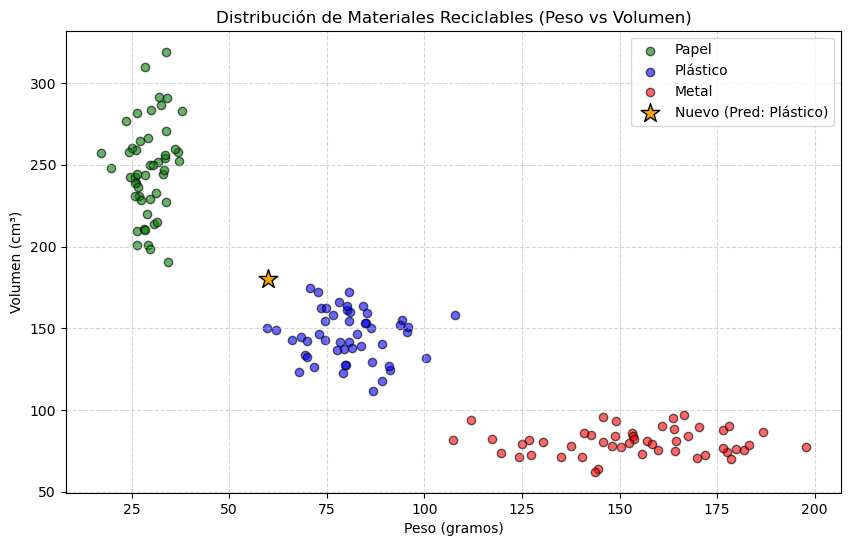

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

class RecyclableItem:

    def __init__(self, weight, volume, material_type):
        self.weight = weight
        self.volume = volume
        self.material_type = material_type

    def to_vector(self):
        return [self.weight, self.volume]

    def __repr__(self):
        material_names = {0: "Papel", 1: "Plástico", 2: "Metal"}
        return f"Item({material_names.get(self.material_type)}, {self.weight:.2f}g, {self.volume:.2f}cm³)"

class RecyclingDataGenerator:
    def __init__(self, num_samples=150):
        self.num_samples = num_samples

    def generate(self):
        items = []
        samples_per_type = self.num_samples // 3
        for _ in range(samples_per_type):
            w = np.random.normal(30, 5)
            v = np.random.normal(250, 30)
            items.append(RecyclableItem(w, v, 0))

        for _ in range(samples_per_type):
            w = np.random.normal(80, 10)
            v = np.random.normal(150, 20)
            items.append(RecyclableItem(w, v, 1))

        for _ in range(samples_per_type):
            w = np.random.normal(150, 20)
            v = np.random.normal(80, 10)
            items.append(RecyclableItem(w, v, 2))
            
        return items

class RecyclableMaterialClassifier:

    def __init__(self, k=5):
        self.model = KNeighborsClassifier(n_neighbors=k)
        
    def _prepare_data(self, records):
        X = np.array([item.to_vector() for item in records])
        y = np.array([item.material_type for item in records])
        return X, y

    def fit(self, records):
        X, y = self._prepare_data(records)
        self.model.fit(X, y)
        print(f"✅ Modelo entrenado con {len(records)} registros.")

    def predict(self, weight, volume):
        prediction = self.model.predict([[weight, volume]])
        return prediction[0]

    def evaluate(self, records):
        X_test, y_test = self._prepare_data(records)
        y_pred = self.model.predict(X_test)
        
        print("\n--- Matriz de Confusión ---")
        print(confusion_matrix(y_test, y_pred))
        
        print("\n--- Reporte de Clasificación ---")
        print(classification_report(y_test, y_pred))

class RecyclablePredictionExample:
    def run(self):
        print("🚀 Iniciando sistema de clasificación de reciclaje inteligente...\n")
        generator = RecyclingDataGenerator(num_samples=150)
        all_items = generator.generate()
        
        df = pd.DataFrame([{
            'weight': item.weight, 
            'volume': item.volume, 
            'label': item.material_type
        } for item in all_items])
        
        train_items, test_items = train_test_split(all_items, test_size=0.3, random_state=42, stratify=df['label'])
        classifier = RecyclableMaterialClassifier(k=5)
        classifier.fit(train_items)
        classifier.evaluate(test_items)
        new_w, new_v = 60, 180
        prediction = classifier.predict(new_w, new_v)
        labels_map = {0: 'Papel', 1: 'Plástico', 2: 'Metal'}
        
        print("📦 Predicción para un nuevo objeto:")
        print(f"   Peso: {new_w}g, Volumen: {new_v}cm³")
        print(f"   Tipo estimado: {labels_map[prediction]}")
        self.visualize(df, new_w, new_v, prediction)

    def visualize(self, df, new_w, new_v, pred_label):
        plt.figure(figsize=(10, 6))
        colors = {0: 'green', 1: 'blue', 2: 'red'}
        labels = {0: 'Papel', 1: 'Plástico', 2: 'Metal'}
        for label_code, color in colors.items():
            subset = df[df['label'] == label_code]
            plt.scatter(subset['weight'], subset['volume'], 
                        c=color, label=labels[label_code], alpha=0.6, edgecolors='k')
        plt.scatter(new_w, new_v, c='orange', s=200, marker='*', 
                    label=f'Nuevo (Pred: {labels[pred_label]})', edgecolors='black')
        
        plt.title('Distribución de Materiales Reciclables (Peso vs Volumen)')
        plt.xlabel('Peso (gramos)')
        plt.ylabel('Volumen (cm³)')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.show()

if __name__ == "__main__":
    example = RecyclablePredictionExample()
    example.run()

# Resultado:

Casos de prueba

Suspenso: 0, Aprobado: 2 de 2 pruebas

F test_classifier_reaches_minimum_accuracy

test_prediction_returns_valid_class